In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.dates as mdates
from datetime import datetime
import calendar
from itertools import groupby
from operator import itemgetter
from scipy.stats import spearmanr, pearsonr
import matplotlib as mpl

## Preparing data

In [3]:
# Load the data
data = pd.read_csv("Kanyapella.csv")

data['avg_temp']=(pd.to_numeric(data['max_temp'])+pd.to_numeric(data['min_temp']))/2
data['Date'] = pd.to_datetime(data['YYYY-MM-DD'], format="%d/%m/%Y")

In [4]:
# Read the data from Russell 1986
trapdata = pd.read_csv("Russell_1986_data_extraction.csv")
trapdata['Date'] = pd.to_datetime(trapdata['Date'], format="%d/%m/%Y")

## Fixed parameters

In [6]:
Gamma_Ao = 2
Gamma_Aem = 1/2.25
Gamma_Ah = 1/1
mu_em = 0.1
mu_r = 0.08
mu_A = 1/43
Kappa_L = 60000
Kappa_P = 750
sigma = 0.5
b = 150

## Temperature dependent parameters

In [8]:
def model_functions(T_values):
    results = []

    for T in T_values:
        f_E = np.maximum(-0.22584167135625277 + 0.02938619991749114 * T, 0)
        f_L = 0.06494664519945703 - 0.0052756957520204584 * T + 0.00024460680510909546 * T**2
        f_P = np.maximum(-0.30242427348916734 + 0.03185883178407586 * T, 0)
        f_Ag = np.maximum(0.012899492899468455 * T - 0.06445926946783458, 0)
        
        m_E = 4.062082185419959 - 0.303551467661088 * T + 0.005760661834651404 * T**2
        m_L = 2.6816120384385735 - 0.2059482508885142 * T + 0.00398441781782507 * T**2
        m_P = 0.41261868432678683 - 0.01768022562916091 * T + 0.0002133140318825642 * T**2
        m_A = np.maximum(-0.013134438602457221 + 0.00252921681275442 * T, mu_A)
        
        results.append((f_E, f_P, f_L, f_Ag, m_E, m_L, m_P, m_A))
        
    return results

In [9]:
T_functions = model_functions(data['avg_temp'].values)

## Defining model

In [11]:
def euler_step(t, y, dt, params, T_functions, period_reset_flag, is_summer_period, start_year=1978):
    # Unpack fixed parameters
    Gamma_Aem, Gamma_Ao, Gamma_Ah, mu_em, mu_r, mu_A, Kappa_L, Kappa_P, sigma, b = params
    
    # Unpack the state variables
    E = y[0]; L = y[1]; P = y[2]; A_em = y[3]
    A_h = y[4]; A_g = y[5]; A_o = y[6]; A_d = y[7]
    
    # Determine the total number of days
    total_days = int(t)
    
    # Unpack temperature-dependent parameters
    f_E, f_P, f_L, f_Ag, m_E, m_L, m_P, m_A = T_functions[total_days]

    # Initialize variables for year and day_of_year
    current_year = start_year
    day_of_year = total_days + 1 # Day of year starts at 1 (since t starts at 0)
    
    # Loop over the years and accumulate the days to determine the correct year
    while True:
        # Get the number of days in the current year (366 for leap year, 365 for normal year)
        days_in_current_year = 366 if calendar.isleap(current_year) else 365
        
        # If the total days exceed the current year's days, move to the next year
        if day_of_year > days_in_current_year:
            day_of_year -= days_in_current_year  # Subtract the days for the next year
            current_year += 1  # Move to the next year
        else:
            # In correct year
            break

    # Calculate derivativens
    if day_of_year <= 81 or day_of_year >= 295: # Set summer periods
        is_summer_period = True
        if not period_reset_flag:
            E = 0
            L = 0
            P = 0
            A_em = 0
            A_h = 0
            A_g = 0
            A_o = 0
            period_reset_flag = True
        phi = 0
        Gamma_Ad = 1/dt
    else:
        is_summer_period = False
        phi = 1
        Gamma_Ad = 0
        period_reset_flag = False

    dE = Gamma_Ao * b * A_o - (m_E + f_E) * E
    dL = f_E * E - (m_L * (1 + L / Kappa_L) + f_L) * L
    dP = f_L * L - (m_P + f_P) * P
    dA_em = f_P * P * sigma * np.exp(-mu_em * (1 + P / Kappa_P)) - (m_A + Gamma_Aem) * A_em
    dA_h = Gamma_Aem * A_em + (1 - phi) * Gamma_Ao * A_o + Gamma_Ad * A_d - (m_A + mu_r + Gamma_Ah) * A_h
    dA_g = Gamma_Ah * A_h - (m_A + f_Ag) * A_g
    dA_o = f_Ag * A_g - (m_A + mu_r + Gamma_Ao) * A_o
    dA_d = phi * Gamma_Ao * A_o - Gamma_Ad * A_d - mu_A * A_d  
    
    # Return updated state variables after one Euler step
    y_new = [
        E + dE * dt,
        L + dL * dt,
        P + dP * dt,
        A_em + dA_em * dt,
        A_h + dA_h * dt,
        A_g + dA_g * dt,
        A_o + dA_o * dt,
        A_d + dA_d * dt,
    ]
    
    return y_new, period_reset_flag, is_summer_period

## Running model

In [13]:
# Initial conditions
E_ini = 0  # Initial number of eggs
L_ini = 0      # Initial number of larvae
P_ini = 0      # Initial number of pupae
A_em_ini = 0   # Initial number of emerging adults
A_h_ini = 1000   # Initial number of females searching for hosts
A_g_ini = 0   # Initial number of females resting after feeding
A_o_ini = 0   # Initial number of females searching for oviposition sites
A_d_ini = 0   # Initial number of diapausing parous adults

# Initial state vector
y_init = [E_ini, L_ini, P_ini, A_em_ini, A_h_ini, A_g_ini, A_o_ini, A_d_ini]

# Set initial values
period_reset_flag = True # True if starting in summer period, false if in winter period
is_summer_period = True
summer_flags = []  # True for summer period, False for winter period

# Time settings
dt = 0.05  # Time step (in days)
t_max = len(data['avg_temp']) # Total time
time_points = np.arange(0, t_max, dt)

results = np.empty((len(time_points[::20]), len(y_init)))

# Initialise parameters (set to appropriate values)
params = [
    Gamma_Aem, Gamma_Ao, Gamma_Ah, mu_em, mu_r, mu_A, Kappa_L, Kappa_P, sigma, b
]

# Run the model using Euler method
y = y_init
for i, t in enumerate(time_points):
    y, period_reset_flag, is_summer_period = euler_step(t, y, dt, params, T_functions, period_reset_flag, is_summer_period)
    if i % 20 == 19:
        results[i // 20] = y
        summer_flags.append(is_summer_period)

In [14]:
E = results[:,0]
L = results[:,1]
P = results[:,2]
A_em = results[:,3]
A_h = results[:,4]
A_g = results[:,5]
A_o = results[:,6]
A_d = results[:,7]

## Performing correlation with Russell trapping data and host-seeking adults in model

In [16]:
# Create DataFrame for A_h
df_Ah = pd.DataFrame({
    'Date': data['Date'],
    'A_h': A_h 
})

### Temperature correlation

In [18]:
# Merge temperature data with trap data on 'Date'
tempdf_russell = pd.merge(data, trapdata, on='Date', how='inner')

In [19]:
# Pearson
temp_r, temp_p_r = pearsonr(tempdf_russell['mosquito_numbers'], tempdf_russell['avg_temp'])

# Assign significance stars
if temp_p_r < 0.001:
    stars = '***'
elif temp_p_r < 0.01:
    stars = '**'
elif temp_p_r < 0.05:
    stars = '*'
else:
    stars = ''

# Spearman
temp_rho, temp_p_s = spearmanr(tempdf_russell['mosquito_numbers'], tempdf_russell['avg_temp'])

# Assign significance stars
if temp_p_s < 0.001:
    stars = '***'
elif temp_p_s < 0.01:
    stars = '**'
elif temp_p_s < 0.05:
    stars = '*'
else:
    stars = ''
    
print(f"Temperature Pearson r = {temp_r:.3f}{stars} (p = {temp_p_r:.3e})")
print(f"Spearman ρ = {temp_rho:.3f}{stars} (p = {temp_p_s:.3e})")

Temperature Pearson r = 0.261*** (p = 1.197e-02)
Spearman ρ = 0.496*** (p = 4.986e-07)


### Model output correlation

In [21]:
# Merge mosquito numbers data with A_h data on 'Date'
merged_trap_model = pd.merge(df_Ah, trapdata, on='Date', how='inner')

In [22]:
# Metrics
r, p_p = pearsonr(merged_trap_model['mosquito_numbers'], merged_trap_model['A_h'])
rho, p_s = spearmanr(merged_trap_model['mosquito_numbers'], merged_trap_model['A_h'])

# Assign significance stars
if p_p < 0.001:
    stars = '***'
elif p_p < 0.01:
    stars = '**'
elif p_p < 0.05:
    stars = '*'
else:
    stars = ''

# Assign significance stars
if p_s < 0.001:
    stars = '***'
elif p_s < 0.01:
    stars = '**'
elif p_s < 0.05:
    stars = '*'
else:
    stars = ''

# Errors
mse = np.mean((merged_trap_model['mosquito_numbers'] - merged_trap_model['A_h'])**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(merged_trap_model['mosquito_numbers'] - merged_trap_model['A_h']))
mbe = np.mean(merged_trap_model['A_h'] - merged_trap_model['mosquito_numbers'])
    
print(f"Pearson r = {r:.3f}{stars} (p = {p_p:.3e})")
print(f"Spearman ρ = {rho:.3f}{stars} (p = {p_s:.3e})")
print(f"RMSE = {rmse:.3f}")
print(f"MAE = {mae:.3f}")
print(f"MBE = {mbe:.3f}")

Pearson r = 0.398*** (p = 8.715e-05)
Spearman ρ = 0.551*** (p = 1.269e-08)
RMSE = 424.965
MAE = 319.052
MBE = 282.439


## Plotting model output and field data

In [24]:
# Total days from September 1, 1979, to April 30, 1985
A_h_adjusted = A_h[243+365:]

# Relevant date range
dates_adjusted = np.arange(np.datetime64('1979-09-01'), np.datetime64('1985-05-01'))

# Shading same length
summer_flags_adjusted = summer_flags[243+365:]

In [25]:
mpl.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 10,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,

    # Axis lines
    "axes.linewidth": 0.5,

    # Tick thickness
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,

    # Tick length (optional but helpful)
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Line plots
    "lines.linewidth": 1,

    # Fonts
    "font.family": "Arial",

    # PDF export
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

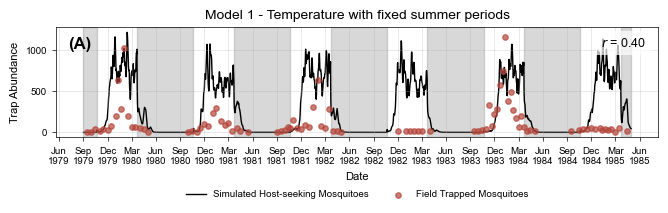

In [26]:
# Plot setup
plt.figure(figsize=(170/25.4, 2))

# Subplot for Mosquito Numbers and A_h
ax1 = plt.subplot(1, 1, 1)
ax1.plot(dates_adjusted[:2069], A_h_adjusted, label='Simulated Host-seeking Mosquitoes', color='black', zorder=1)
ax1.scatter(merged_trap_model['Date'], merged_trap_model['mosquito_numbers'], color='#B4463A', alpha=0.7, s=15, zorder=2, label='Field Trapped Mosquitoes')
ax1.set_title('Model 1 - Temperature with fixed summer periods')
ax1.set_xlabel('Date')
ax1.set_ylabel('Trap Abundance')
ax1.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.4),
    ncol=2,
    frameon=False
)
ax1.grid(True, linewidth = 0.4, alpha = 0.5)
# Set major ticks to every 3 months — Dec, Mar, Jun, Sep
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[12, 3, 6, 9]))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax1.tick_params(axis='both')

# Shade winter periods
winter_indexes = [i for i, f in enumerate(summer_flags_adjusted[:2069]) if not f]
for k, g in groupby(enumerate(winter_indexes), lambda ix: ix[0] - ix[1]):
    group = list(map(itemgetter(1), g))
    start_date = dates_adjusted[group[0]]
    end_date = dates_adjusted[group[-1]]
    ax1.axvspan(start_date, end_date, color="grey", alpha=0.3, zorder=0)

# Add Pearson's r text
ax1.text(
    0.98, 0.92,
    fr'$r$ = {r:.2f}',
    transform=ax1.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
)

# Add panel label (A) in bold in the top left
ax1.text(
    0.02, 0.92,
    '(A)', 
    transform=ax1.transAxes,
    fontsize=12,
    fontweight='bold',
    verticalalignment='top',
    horizontalalignment='left'
)

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.88,
    bottom=0.33
)

# Show the plot
plt.show()